In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline



df_clean = pd.read_csv("data_cleaned.csv")
print(df_clean.shape)

(125973, 124)


In [2]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [3]:
def compute_cost(X,y,w,b):
    m=len(y)
    z=np.dot(X,w) + b
    predctions = sigmoid(z)
    epsilon = 1e-9
    cost= -(1/m) * np.sum(y * np.log(predctions+epsilon) + (1-y)*np.log(1-predctions+epsilon))
    return cost


In [4]:
print(sigmoid(0))
print(sigmoid(10))
print(sigmoid(-10))

0.5
0.9999546021312976
4.5397868702434395e-05


In [5]:
def gradiant_descent(X,y,w,b,learning_rate,iterations):
    m=len(y)
    cost_history = []
    for i in range(iterations):
        z=np.dot(X,w) + b
        predctions=sigmoid(z)

        dw=(1/m)*np.dot(X.T,(predctions-y))
        db=(1/m)*np.sum(predctions-y)

        w -= learning_rate*dw
        b -= learning_rate*db

        cost_history.append(compute_cost(X,y,w,b))
        if i%100 == 0:
            print (f"Iteration{i}:cost={cost_history[-1]:.4f}")
    return w,b,cost_history    

     

        

In [10]:
X=df_clean.drop(columns='attack_flag').values
y=df_clean['attack_flag'].values

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

w = np.zeros(X_train.shape[1])
b=0
w,b,cost_history=gradiant_descent(X_train,y_train,w,b,learning_rate=0.1,iterations=1000)


Iteration0:cost=0.5423
Iteration100:cost=0.0824
Iteration200:cost=0.0663
Iteration300:cost=0.0592
Iteration400:cost=0.0550
Iteration500:cost=0.0522
Iteration600:cost=0.0502
Iteration700:cost=0.0486
Iteration800:cost=0.0474
Iteration900:cost=0.0465


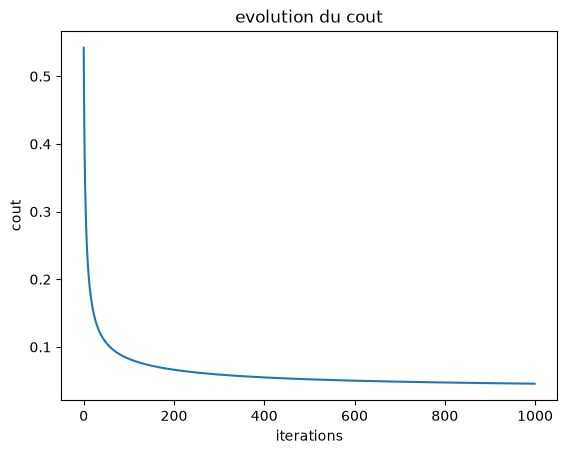

In [8]:
plt.plot(cost_history)
plt.title('evolution du cout')
plt.xlabel('iterations')
plt.ylabel('cout')
plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
sklearn_model = LogisticRegression(max_iter=2000)
sklearn_model.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [14]:
from sklearn.metrics import  accuracy_score
z=np.dot(X_test,w)+b
y_pred_scratch = (sigmoid(z) >= 0.5).astype(int)
y_pred_sklearn = sklearn_model.predict(X_test)
print ("accuracy from scratch:", accuracy_score(y_test, y_pred_scratch))
print("accuracy sklearn:",accuracy_score(y_test,y_pred_sklearn))

accuracy from scratch: 0.986346497320897
accuracy sklearn: 0.9892835880134947


In [15]:
agreement=(y_pred_scratch == y_pred_sklearn).mean()
print(f"les deux modeles sont d accord sur {agreement*100:.2f}%des predection")


les deux modeles sont d accord sur 99.32%des predection
